# OISST v2.1 전처리 — 일별 → 월평균 (3-도메인)

1. 전체 기간(1993–2024) 일별 파일 로드
2. 북서태평양 도메인 서브셋 3종
   - **a** : lat 0–60°N, lon 100–180°E (원격 장제력 / 대역 탐색)
   - **b** : lat 10–45°N, lon 120–180°E
   - **c** : lat 20–35°N, lon 125–150°E (core)
3. 월평균 SST + 유효 일수(count) 계산
4. 도메인별 NetCDF 저장

**메모**: 11,688개 파일을 한 번에 열면 파일 핸들 초과로 커널 크래시 → 연도별 루프 후 `xr.concat`  
도메인 a (최대)로 루프, 이후 b/c는 sel()로 서브셋

## 0. 임포트 및 경로 설정

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── 경로 ──────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data/raw/oisst_v21/daily")
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── 도메인 3종 260401에 수정 ──────────────────────────────────────────── 
DOMAINS ={
    "a": {"lat": (15.0, 45.0), "lon" : (120.0, 180.0)}, # local WNP box
    "b": {"lat": (-10.0, 45.0), "lon" : (110.0, 180.0)}, # tropical-WNP connected box
    "c": {"lat": (20.0, 65.0), "lon" : (110.0, 220.0)}, # broader Pacific box
}

YEARS = range(1993, 2025)   # 1993–2024

print(f"일별 파일 수: {len(sorted(DATA_DIR.glob('*.nc')))}")
print(f"처리 연도  : {YEARS.start} – {YEARS.stop - 1}")
print("\n도메인:")
for k, d in DOMAINS.items():
    print(f"  {k}: lat {d['lat']}, lon {d['lon']}")

In [2]:
'''
problem_file = DATA_DIR / "oisst-avhrr-v02r01.19941030.nc"

ds_test = xr.open_dataset(problem_file)
ds_test
'''

'\nproblem_file = DATA_DIR / "oisst-avhrr-v02r01.19941030.nc"\n\nds_test = xr.open_dataset(problem_file)\nds_test\n'

In [3]:
# 260323 손상 파일 확인
# 11688 개 파일 중 4개가 특이하게 파일 크기가 낮아, 검사 -> 삭제 -> 재다운로드를 진행하였음.

'''
all_files = sorted(DATA_DIR.glob("oisst-avhrr-v02r01.*.nc"))
sizes = [(f, f.stat().st_size) for f in all_files]

size_vals = np.array([s for _, s in sizes])
median_mb = np.median(size_vals) / 1e6
threshold = np.median(size_vals) * 0.85

suspect_files = [f for f, s in sizes if s < threshold]

print(len(sizes))
print(median_mb)
print(threshold/1e6)
print(len(suspect_files))
'''

'\nall_files = sorted(DATA_DIR.glob("oisst-avhrr-v02r01.*.nc"))\nsizes = [(f, f.stat().st_size) for f in all_files]\n\nsize_vals = np.array([s for _, s in sizes])\nmedian_mb = np.median(size_vals) / 1e6\nthreshold = np.median(size_vals) * 0.85\n\nsuspect_files = [f for f, s in sizes if s < threshold]\n\nprint(len(sizes))\nprint(median_mb)\nprint(threshold/1e6)\nprint(len(suspect_files))\n'

In [4]:
''' 
bad_files = []

for f in suspect_files:
    try:
        ds_tmp = xr.open_dataset(f)
        ds_tmp.close()
    except Exception as e:
        bad_files.append((f.name, f.stat().st_size / 1e6, str(e)[:60]))

print(f"의심 파일 수: {len(bad_files)}")
if bad_files:
    for fname, sz, err in bad_files:
        print(f"  {fname:<44} {sz:6.2f}  {err}")
'''

' \nbad_files = []\n\nfor f in suspect_files:\n    try:\n        ds_tmp = xr.open_dataset(f)\n        ds_tmp.close()\n    except Exception as e:\n        bad_files.append((f.name, f.stat().st_size / 1e6, str(e)[:60]))\n\nprint(f"의심 파일 수: {len(bad_files)}")\nif bad_files:\n    for fname, sz, err in bad_files:\n        print(f"  {fname:<44} {sz:6.2f}  {err}")\n'

In [5]:
# 파일이 아예 열리지 않는 현상이 발생해서, 전체 파일에 대해 검사.
"""
monthly_list = []
count_list   = []
bad_files    = []   # 손상 파일 수집

for year in YEARS:
    files = sorted(DATA_DIR.glob(f"oisst-avhrr-v02r01.{year}*.nc"))
    if not files:
        print(f"  {year}: 파일 없음 — 건너뜀")
        continue

    # 파일별 열기 테스트 → 손상 파일 제외
    good_files = []
    for f in files:
        try:
            ds_tmp = xr.open_dataset(f)
            ds_tmp.close()
            good_files.append(f)
        except Exception:
            bad_files.append(f.name)

    if not good_files:
        print(f"  {year}: 유효 파일 없음 — 건너뜀")
        continue

    skipped = len(files) - len(good_files)
    if skipped:
        print(f"  {year}: 손상 {skipped}개 제외 → {[f for f in files if f not in good_files]}")

    ds = xr.open_mfdataset(good_files, combine="by_coords", parallel=False)
    sst = (
        ds["sst"]
        .squeeze("zlev", drop=True)
        .sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))
    )

    mean_yr  = sst.resample(time="MS").mean().compute()
    count_yr = sst.resample(time="MS").count().compute()

    monthly_list.append(mean_yr)
    count_list.append(count_yr)
    ds.close()
    print(f"  {year}: {len(good_files):3d}일, {len(mean_yr.time)}개월 처리 완료")

print("\n루프 완료.")
if bad_files:
    print(f"\n손상 파일 목록 ({len(bad_files)}개):")
    for f in bad_files:
        print(f"  {f}")
"""

'\nmonthly_list = []\ncount_list   = []\nbad_files    = []   # 손상 파일 수집\n\nfor year in YEARS:\n    files = sorted(DATA_DIR.glob(f"oisst-avhrr-v02r01.{year}*.nc"))\n    if not files:\n        print(f"  {year}: 파일 없음 — 건너뜀")\n        continue\n\n    # 파일별 열기 테스트 → 손상 파일 제외\n    good_files = []\n    for f in files:\n        try:\n            ds_tmp = xr.open_dataset(f)\n            ds_tmp.close()\n            good_files.append(f)\n        except Exception:\n            bad_files.append(f.name)\n\n    if not good_files:\n        print(f"  {year}: 유효 파일 없음 — 건너뜀")\n        continue\n\n    skipped = len(files) - len(good_files)\n    if skipped:\n        print(f"  {year}: 손상 {skipped}개 제외 → {[f for f in files if f not in good_files]}")\n\n    ds = xr.open_mfdataset(good_files, combine="by_coords", parallel=False)\n    sst = (\n        ds["sst"]\n        .squeeze("zlev", drop=True)\n        .sel(lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX))\n    )\n\n    mean_yr  = sst.resample(tim

## 1. 연도별 루프 — 도메인 a 기준 월평균 & 유효 일수 계산

- 도메인 a (가장 큰 영역)로 루프 → concat 후 b/c는 sel()로 서브셋
- 한 번에 한 해씩 열고 → 서브셋 → 월평균/count → `.compute()` → 닫기
- 손상 파일(HDF error)은 try/except로 건너뜀

In [ ]:
lat_min_a, lat_max_a = DOMAINS["a"]["lat"]
lon_min_a, lon_max_a = DOMAINS["a"]["lon"]

monthly_list = []   # 연도별 월평균 SST  (domain a)
count_list   = []   # 연도별 유효 일수   (domain a)
bad_files    = []

for year in YEARS:
    files = sorted(DATA_DIR.glob(f"oisst-avhrr-v02r01.{year}*.nc"))
    if not files:
        print(f"  {year}: 파일 없음 — 건너뜀")
        continue

    # 손상 파일 제외 (HDF error 등)
    good_files = []
    for f in files:
        try:
            ds_tmp = xr.open_dataset(f)
            ds_tmp.close()
            good_files.append(f)
        except Exception:
            bad_files.append(f.name)

    if not good_files:
        print(f"  {year}: 유효 파일 없음 — 건너뜀")
        continue

    if len(good_files) < len(files):
        skipped = [f.name for f in files if f not in good_files]
        print(f"  {year}: 손상 {len(skipped)}개 제외 → {skipped}")

    ds = xr.open_mfdataset(good_files, combine="by_coords", parallel=False)
    sst = (
        ds["sst"]
        .squeeze("zlev", drop=True)
        .sel(lat=slice(lat_min_a, lat_max_a), lon=slice(lon_min_a, lon_max_a))
    )

    mean_yr  = sst.resample(time="MS").mean().compute()
    count_yr = sst.resample(time="MS").count().compute()

    monthly_list.append(mean_yr)
    count_list.append(count_yr)
    ds.close()
    print(f"  {year}: {len(good_files):3d}일, {len(mean_yr.time)}개월 처리 완료")

print("\n루프 완료.")
if bad_files:
    print(f"\n손상 파일 목록 ({len(bad_files)}개):")
    for f in bad_files:
        print(f"  {f}")

In [ ]:
# ── 전체 기간 concat (domain a) ─────────────────────────────────────
sst_a = xr.concat(monthly_list, dim="time")
count_a = xr.concat(count_list,   dim="time")

# ── b, c는 sel()로 서브셋 ─────────────────────────────────────────────
sst_b = sst_a.sel(lat=slice(*DOMAINS["b"]["lat"]), lon=slice(*DOMAINS["b"]["lon"]))
sst_c = sst_a.sel(lat=slice(*DOMAINS["c"]["lat"]), lon=slice(*DOMAINS["c"]["lon"]))

SST   = {"a": sst_a,   "b": sst_b,   "c": sst_c}
COUNT = {"a": count_a, "b": None,     "c": None}   # count는 a만 진단용

for k, s in SST.items():
    print(f"domain {k}: {dict(s.sizes)}")

## 2. 유효 일수(count) 진단

각 격자 × 각 (연도, 월)에 대해 비-NaN 일수를 집계하고,  
격자별 **최솟값**을 지도·히스토그램·시계열로 시각화한다.

In [ ]:
# 해양 마스크: 모든 월에 걸쳐 SST가 하나라도 유효한 격자 (domain a 기준)
ocean_mask = ~sst_a.isnull().all(dim="time")

# 격자별 worst-case 유효 일수
count_min = count_a.min(dim="time")

vals = count_min.values[ocean_mask.values]
print("=== domain a 해양 격자 worst-case 유효 일수 통계 ===")
print(f"  min   : {vals.min()}")
print(f"  p01   : {np.percentile(vals,  1):.1f}")
print(f"  p05   : {np.percentile(vals,  5):.1f}")
print(f"  median: {np.median(vals):.1f}")
print(f"  mean  : {vals.mean():.2f}")

In [ ]:
# 격자별 최소 유효 일수 지도 (domain a)
fig, ax = plt.subplots(figsize=(10, 6))
count_min.where(ocean_mask).plot(
    ax=ax, cmap="YlOrRd_r", vmin=0,
    cbar_kwargs={"label": "최소 유효 일수 (days)"},
)
ax.set_title("domain a — worst-case 유효 일수")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
plt.tight_layout()
plt.savefig(FIG_DIR / "oisst_count_min_map.png", dpi=150)
plt.show()

C:\Users\dnjst\AppData\Local\Temp\ipykernel_20020\1534976529.py:9: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_20020\1534976529.py:9: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_20020\1534976529.py:9: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_20020\1534976529.py:9: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_20020\1534976529.py:9: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dnjst\AppData\Local\Temp\ipykernel_20020\1534976529.py:9: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) 

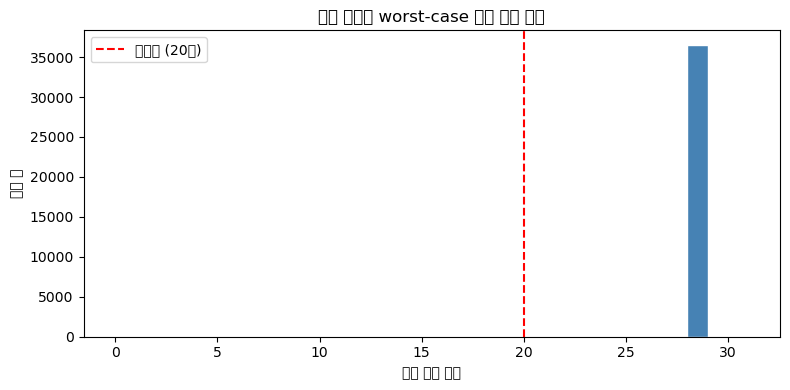

In [10]:
# 유효 일수 히스토그램
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(vals, bins=range(0, 32), edgecolor="white", color="steelblue")
ax.axvline(20, color="red", linestyle="--", label="참고선 (20일)")
ax.set_xlabel("최소 유효 일수")
ax.set_ylabel("격자 수")
ax.set_title("해양 격자별 worst-case 유효 일수 분포")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "oisst_count_min_hist.png", dpi=150)
plt.show()

In [ ]:
# 도메인 a 해양 평균 유효 일수 시계열
count_ocean_mean = count_a.where(ocean_mask).mean(dim=["lat", "lon"])

fig, ax = plt.subplots(figsize=(14, 4))
count_ocean_mean.plot(ax=ax, color="steelblue", linewidth=0.8)
ax.axhline(20, color="red", linestyle="--", label="참고선 (20일)")
ax.set_title("domain a 해양 격자 평균 유효 일수 시계열")
ax.set_ylabel("평균 유효 일수")
ax.set_xlabel("시간")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "oisst_count_timeseries.png", dpi=150)
plt.show()

## 3. 도메인별 월평균 SST 저장

In [ ]:
for k, sst in SST.items():
    d = DOMAINS[k]
    sst.attrs.update({
        "long_name"    : "Monthly mean sea surface temperature",
        "units"        : "Celsius",
        "source"       : "OISST v2.1 AVHRR-only daily → monthly mean (resample MS)",
        "domain"       : f"lat {d['lat'][0]}–{d['lat'][1]}N, lon {d['lon'][0]}–{d['lon'][1]}E",
        "time_coverage": "1993-01 to 2024-12",
    })
    out_path = OUTPUT_DIR / f"oisst_monthly_nwpacific_domain{k}_1993_2024.nc"
    sst.to_dataset(name="sst").to_netcdf(
        out_path,
        encoding={"sst": {"zlib": True, "complevel": 4, "dtype": "float32"}},
    )
    print(f"저장 완료: {out_path.name}  {dict(sst.sizes)}")

## 4. 저장 파일 검증

In [ ]:
for k in DOMAINS:
    path = OUTPUT_DIR / f"oisst_monthly_nwpacific_domain{k}_1993_2024.nc"
    ds_chk = xr.open_dataset(path)
    nan_pct = float(ds_chk["sst"].isnull().mean().values) * 100
    print(f"domain {k}: {dict(ds_chk['sst'].sizes)}  NaN {nan_pct:.1f}%  "
          f"time {str(ds_chk.time.values[0])[:10]} ~ {str(ds_chk.time.values[-1])[:10]}")
    ds_chk.close()